In [33]:
#импорт всех библиотек, которые я буду использовать
import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np
from collections import defaultdict
import json

In [34]:
sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

# sessions — список списков целых чисел
# print(f"Всего сессий: {len(sessions)}")
# print(f"Первая сессия: {sessions}")


**ПУНКТ 1 - Анализ данных**

### Количество сессий и уникальных товаров, распределение длин сессий

In [35]:
#число сессий:
ses_q = len(sessions)
print(f"Число сессий: {ses_q}")

#число уникальных товаров НЕВЕРНО
#число уникальных товаров
uniq_good = set()
for i in range(len(sessions)):
    uniq_good.update(sessions[i])
good_q = len(uniq_good)
print(f"Число уникальных товаров: {good_q}")

Число сессий: 2565
Число уникальных товаров: 400


Статистика длин сессий:


,count,mean,std,min,25%,50%,75%,max
session_length,2565.0,10.465107,5.904932,3.0,5.0,9.0,16.0,20.0


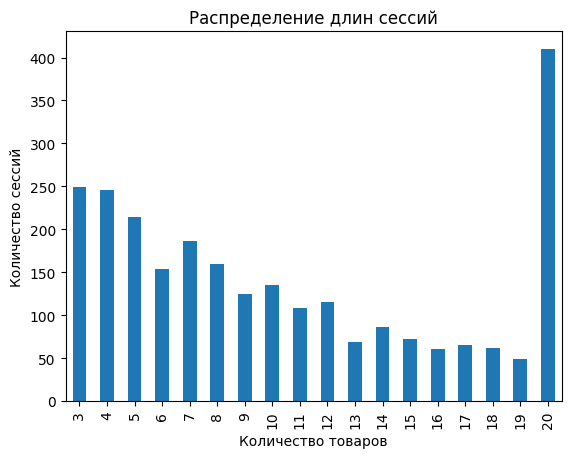

In [36]:
#распределение длин сессий
len_ses = [len(s) for s in sessions]
df = pd.DataFrame(len_ses, columns=['session_length'])


print("Статистика длин сессий:")
display(df.describe().T)

#покажу на графике
df['session_length'].value_counts().sort_index().plot(kind='bar')

plt.title('Распределение длин сессий')
plt.xlabel('Количество товаров')
plt.ylabel('Количество сессий')
plt.show()

In [37]:
# Разбивка на логические группы
def length_group(length):
    if length <= 5: return "3-5(short)"
    elif length <= 10: return "6-10(medium)"
    elif length <= 15: return "11-15(long)"
    return "16-20(very long)"

df['group'] = [length_group(l) for l in len_ses]

group_stats = df.groupby('group')['group'].count().to_frame('quantity')
group_stats = group_stats.reindex([
    "3-5(short)",
    "6-10(medium)",
    "11-15(long)",
    "16-20(very long)"
])
group_stats


,quantity
group,
3-5(short),709
6-10(medium),760
11-15(long),450
16-20(very long),646


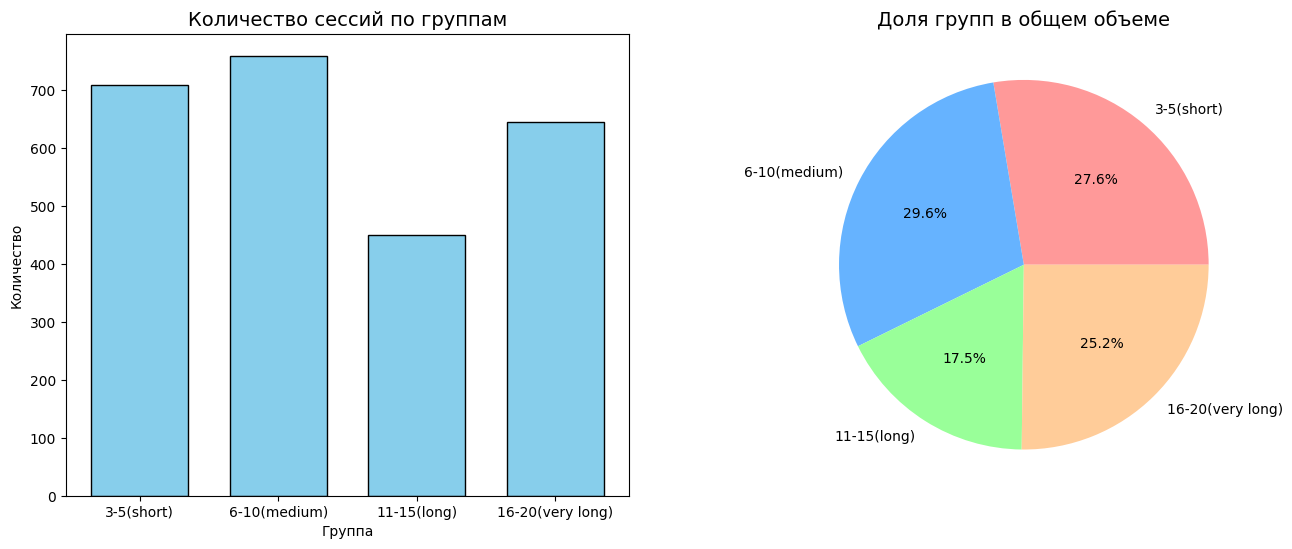

In [38]:
#также построю ба-чарт и пай-чарт
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)  
plt.bar(
    group_stats.index,
    group_stats['quantity'],
    color='skyblue',
    edgecolor='black',
    linewidth=1.0,
    width=0.7
)
plt.title('Количество сессий по группам', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Количество')
plt.subplot(1, 2, 2)
plt.pie(
    group_stats['quantity'],
    labels=group_stats.index,
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
plt.title('Доля групп в общем объеме', fontsize=14)

plt.show()

**Вывод:** 
1. В датасете содержится 2565 сессий и 400 уникальных товаров. Длина сессий варьируется от 3 до 20 товаров, средняя длина составляет примерно 10.47, а медианная — 9 товаров.

2. Больше всего сессий находится в диапазоне 6–10 товаров = 760 сессий(29.6%). Короткие сессии 3–5 товаров также встречаются часто = 709 сессий(27.6%).

3. Самая маленькая группа — сессии длиной 11–15 товаров: 450 сессий(17.5%). При этом кол-во длинных сессий 16–20 товаров = 646 сессий(25.2%).**Особенно** выделяется длина 20, что может указывать на ограничение максимальной длины сессии в датасете.

### Анализ самых популярных/непопулярных товаров

In [39]:
#самые просматриваемые товары
product_counts = pd.Series([item for session in sessions for item in session])
#общее число просмотров:
full_watching = len(product_counts)

#создаю датафрейм, где значением count будет являться кол-во просмотров данного товара
product_df = product_counts.value_counts().to_frame(name='views').rename_axis('item_id')  #.reset_index() #как сделать по нормальному, чтоб индексом был айтем


In [40]:
display(product_df.describe().T)
print()
print("Топ 10 самых покупаемых товаров:")
display(product_df.head(10).T)
print()
print("10 самых непопулярных товаров:")
display(product_df.tail(10).sort_values('views').T)

,count,mean,std,min,25%,50%,75%,max
views,400.0,67.1075,202.234178,5.0,16.0,22.0,45.0,2914.0



Топ 10 самых покупаемых товаров:


item_id,54,335,53,114,260,293,380,212,329,257
views,2914,1691,1223,1067,833,736,571,510,492,450



10 самых непопулярных товаров:


item_id,184,305,326,118,291,117,206,172,220,274
views,5,5,6,6,7,7,8,8,8,8


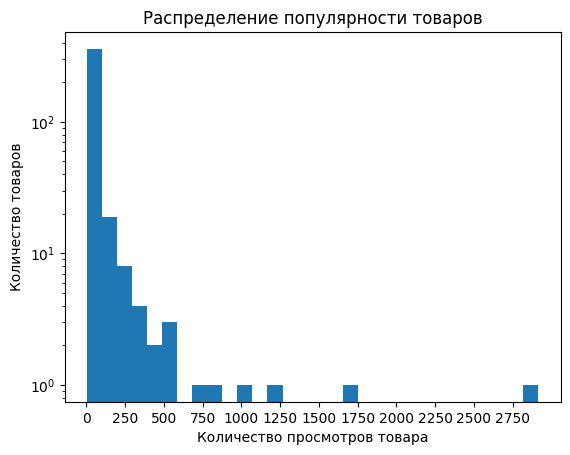

In [41]:
#построил гистограмму распределения товаров
plt.hist(product_df['views'], bins=30)
plt.title("Распределение популярности товаров")
plt.xlabel("Количество просмотров товара")
plt.ylabel("Количество товаров")
plt.xticks(range(0, product_df['views'].max() + 1, 250))
plt.yticks(range(0, 400, 50))

plt.yscale('log')

plt.show()

In [42]:
#сколько топ 10 товаров занимают просмотров в процентном соотношении

top_10_percent = product_df.head(10)['views'].sum() / full_watching * 100
print(f"Процентный покатель товаров, занимающих топ 10 по просмотрам от всех просмотров = {round(top_10_percent,2)}%")

Процентный покатель товаров, занимающих топ 10 по просмотрам от всех просмотров = 39.07%


**Вывод:**
По гистограмме четко видно, что популярность товаров распределена неравномерно. 50% товаров имеют <= 22 просмотров(см. медиану), а небольшая группа товаров является очень популярной. Также хочется подчеркнуть, что 10 самых популярных товаров берун на себя 39.07% просмотров.

### Количество и процентный показатель сессий, в которых товары повторяются

In [43]:
rep = 0
for session in sessions:
    if len(session) != len(set(session)):
        rep += 1
percent = rep/len(sessions)* 100
print("Кол-во сессий с повторениями:", rep)
print("Процент таких сессий :",round(percent,2))

Кол-во сессий с повторениями: 1552
Процент таких сессий : 60.51


**Вывод:** Более 60% сессий содержат повторный просмотры товаров, что говорит о том, что пользователи возращаются к ранее проссмотренным товарам, скорее всего проводя сравненения.

**Проверим, есть ли переходы в один и тот же товар**

In [44]:
self_trans = total_trans = 0
for session in sessions:
    for i in range(len(session)-1):
        total_trans += 1
        if session[i] == session[i+1]:
            self_trans += 1
if self_trans == 0:
    print("Переходов типа [40 -> 40] не найдено")
else:
    print("Количество переходов типа [40 -> 40] =", self_trans)

Переходов типа [40 -> 40] не найдено


**Вывод:** подряд идущих повторов одного и того же товара не обнаружено.
Это значит, что пользователи не открывают один и тот же товар два или несколько раз подряд, но при этом
могут возвращаться к нему позже после просмотра других товаров. Получается, что технической ошибки нет, а значит, что
повторы в сессиях связаны с сравнением товаров.

### Связь частоты появления товара со средней длиной сессии

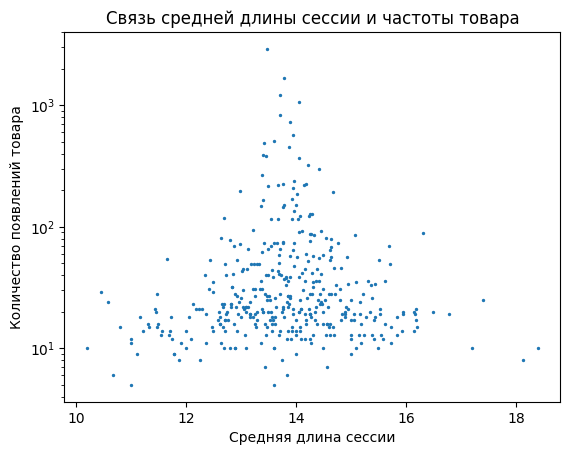

In [45]:
dict_item = defaultdict(list)

for session in sessions:
    for item in session:
        dict_item[item].append(len(session))


lst_mean = []
lst_len = []

for item, lengths in dict_item.items():
    mean_length = np.array(lengths).mean()
    count_item = len(lengths)

    lst_mean.append(mean_length)
    lst_len.append(count_item)


plt.scatter(lst_mean, lst_len, s=2)
plt.yscale('log')
plt.xlabel('Средняя длина сессии')
plt.ylabel('Количество появлений товара')
plt.title('Связь средней длины сессии и частоты товара')
plt.show()

**Вывод:** большинство товаров встречается в сессиях со средней длиной около 13–15 товаров. Наиболее часто встречающиеся товары также сосредоточены в этой области.

### Общий вывод по анализу

1. В датасете есть 2565 сессий, 400 уникальных товаров, а средняя длина сессии составляет около 10.47 товара.

2. Сессии достаточно разнообразны: чаще всего пользователи просматривают 6–10 товаров, но также заметна доля длинных сессий 16–20 товаров. Особенно выделяется длина 20, что может говорить об ограничении максимальной длины сессии.

3. Популярность товаров распределена неравномерно: большинство товаров просматривается редко, а небольшая группа собирает большую часть просмотров. Например, 10 самых популярных товаров дают 39.07% всех просмотров, поэтому их можно использовать как fallback-рекомендации.

4. Также более 60% сессий содержат повторные просмотры товаров, но подряд идущих повторов нет. Это говорит о том, что пользователи возвращаются к товарам позже, вероятно, сравнивая разные варианты.

**Итог:** в данных хорошо прослеживаются пользовательские паттерны, поэтому для задачи подходит модель на основе графа переходов между товарами с **добавлением популярных товаров при нехватке рекомендаций**.

**ПУНКТ 2 - Train/test split**

In [46]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    """
    Разбиение сессий на train и test.

    Для каждой сессии:
      - все товары кроме последнего становятся
        обучающей сессией
      - последний товар становится тестовой целью

    Возвращаемые списки выровнены по индексу:
    test_targets[i] — товар, который нужно
    предсказать по train_sessions[i] как истории.

    Parameters
    ----------
    sessions : list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 3 товаров.

    Returns
    -------
    train_sessions : list of lists of ints
        Сессии для обучения (исходные без последнего товара).
    test_targets : list of ints
        Следующий товар для предсказания по каждой сессии.
    """
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

**Вывод:** При использовании случайных разбиейний граф на train будет построен с учетом данных, которые находятся в будущем относительно тестового товара. Таким образом мы заглянем в будущее (относительно тестового товара)

**ПУНКТ 3,5 - Граф переходов и рекомендательная модель**

In [47]:
#проведу весь датасет через функцию
train_sessions, test_targets = train_test_split(sessions)

**Реализация подсчета вероятностей**
Я реализовал две модели, логика их работы такая:

Я реализовал три модели, логика их работы такая:

1. Подсчет простой вероятности

Подсчет простой вероятности P(k∣n)=a/b, где a — кол-во переходов в товар k из товара n, а b — общее кол-во переходов из товара n в другие товары.

Также я обработал редкие и не встретившиеся переходы. Так как после анализа данных(см. п. 1) есть небольшое количество товаров с огромными просмотрами, то я предполагаю, что вероятность попадания популярного товара высока. Поэтому, если не набирается 8(почему не 10 - см. **Дополнительно**) товаров для рекомендаций, то есть из якорного товара на обучающей выборке было менее 8 исходящих дуг или переходов нет совсем, список заполняется популярными товарами.

2. Подсчет вероятности по Уилсону

Подсчет вероятности по нижней границе доверительного интервала Уилсона 95%, который статистически сглаживает оценки, не позволяя редким переходам получать завышенную вероятность.

Алгоритм суммирует взвешенные вероятности двух последних товаров сессии с коэффициентами влияния 1.0 и 0.5 соответственно. Если уникальных кандидатов мало или переходов нет, список аналогично дополняется глобальным топом популярных товаров.

3. Подсчет простой вероятности по двум последним товарам

Также я реализовал модель, которая учитывает два последних товара сессии, но без использования Уилсона. Вероятность считается обычным способом P(k∣n)=a/b, но итоговый score кандидата считается как сумма взвешенных вероятностей для двух последних товаров сессии с коэффициентами 1.0 и 0.5 соответственно. Если уникальных кандидатов мало или переходов нет, список также дополняется глобальным топом популярных товаров.

**Дополнительно**

В итоговый список рекомендаций модель добавляет не более 8 товаров по вероятностям переходов, а оставшиеся места заполняет глобально популярными товарами. Такое решение было принято на основе EDA: в данных есть несколько товаров с очень большим числом просмотров(были взяты топ-2), поэтому популярные товары имеют высокую вероятность оказаться правильной рекомендацией. Таким образом, модель учитывает не только локальные переходы между товарами, но и общую популярность товаров в датасете.

**Примечание 1**

Для модели, которая учитывает только последний товар, Уилсон не влияет на итоговый порядок рекомендаций, так как все переходы считаются из одного и того же якорного товара. Поэтому Уилсон имеет смысл проверять именно при учете двух или более последних товаров.

**Примечение 2** в коде я описал комментариями интересные переходы

In [48]:
from abc import ABC, abstractmethod
from typing import Dict, List

class Base:
    def __init__(self) -> None:
        self.graph: dict[int, dict[int, int]] = {}
        self.global_top: list[int]  = []

    def create_graph_top_items(self, sessions: list[list[int]]) -> None:
        item_counts: dict[int, int] = {}
        for session in sessions:
            for i in range(len(session)):

                #считаю кол-во просмотров для каждого товара, чтобы потом определитть самые популярные
                item = session[i]
                if item in item_counts:
                    item_counts[item] += 1
                else:
                    item_counts[item] = 1


                #здесь я добавляю переходы товара k в другой товар и кол-во таких переходов
                if i < len(session) - 1:
                    first = session[i]
                    second = session[i+1]

                if first not in self.graph:
                    self.graph[first] = {}

                if second in self.graph[first]:
                    self.graph[first][second] += 1
                else:
                    self.graph[first][second] = 1

        #создал словарь, где будут 10 самых популярных товаров по просмотрам
        self.global_top = sorted(item_counts, key=item_counts.get, reverse=True)[:10]


    def _finalize_rec(self, scored_neighbors: list[tuple[int, float]], current_item: int) -> list[int]:
        # сортирую вероятности перехода для k-го товара
        scored_neighbors.sort(key=lambda x: x[1], reverse=True)

        recommendations = [item[0] for item in scored_neighbors][:8]  

        # добавляю популярные товары, если нужно
        if len(recommendations) < 10:
            for top_item in self.global_top:
                if top_item not in recommendations and top_item != current_item:
                    recommendations.append(top_item)
                if len(recommendations) == 10:
                    break
        return recommendations

    @abstractmethod
    def predict(self, session: list[int]) -> list[int]:
        pass

    @abstractmethod
    def get_probability(self, id1: int, id2: int, total: int) -> float:
        pass


In [49]:
# создал класс наследник для простого вычисления вероятности(кол-во переходов в товар k из товара n/кол-во переходов в другие товвары из товара n)
class SimpleProbModel(Base):
    def get_probability(self, id1: int, id2: int, total: int) -> float:
        if total == 0: return 0.0
        count = self.graph[id1].get(id2, 0)
        return count / total

    def predict(self, session: list[int]) -> list[int]:
        current_item = session[-1]
        #проверяю, а есть ли вообще переходы? Если нет, то возвращаю топ-товары по просмотрам
        if current_item not in self.graph:
            return self.global_top

        #считаю кол-во переходов в доступные товвары из товара n
        neighbors = self.graph[current_item]
        total = sum(neighbors.values())

        #создаю массив переходов с вероятностями
        score_neighbors = []
        for neighbor_id in neighbors:
            score = self.get_probability(current_item, neighbor_id, total)
            score_neighbors.append((neighbor_id, score))

        #далее обращаюсь к классу Base для сортировки и добавки популярных товаров при необходимости
        return self._finalize_rec(score_neighbors, current_item)

In [50]:
class WilsonProbModel(Base):
    #функция доверительного интервала Уильсона и рассчета нижней границы интервала с коэф. доверия 95%
    def _wilson_score(self, count: int, total: int) -> float:
        if total == 0: return 0.0
        z = 1.96
        phat = count / total #оценка вероятности
        centre_point = phat + z**2/(2*total)
        delta = z * math.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total)
        numerator = centre_point - delta
        denominator = 1 + z**2/total
        return numerator / denominator

    def get_probability(self, id1: int, id2: int, total: int) -> float:
        count = self.graph[id1].get(id2, 0)
        return self._wilson_score(count, total)

    def predict(self, session: list[int]) -> list[int]:
        candidate_score: dict[int,float] = {}
        # Задаю веса для двух шагов
        weights = {'last': 1.0, 'prev': 0.5}
        steps = [('last', -1), ('prev', -2)]

        for step, ind in steps:
            current_item = session[ind]

            if current_item in self.graph:  #если нет в двух итерациях, ошибки никакой не будет, мой код все равно в конце вызовет self._finalize_recs(scored_neighbors), где добавит топ 10
                neighbors = self.graph[current_item]
                total = sum(neighbors.values())

                for neighbor_id in neighbors:
                    score = self.get_probability(current_item, neighbor_id, total)

                    # Накапление баллов с учетом веса шага
                    candidate_score[neighbor_id] = candidate_score.get(neighbor_id, 0) + (score * weights[step])

        score_neighbors = list(candidate_score.items())
        return self._finalize_rec(score_neighbors, session[-1])

In [51]:
#идея создания такой модели у меня возникла в связи с проверкой "а работает ли уильсон на моих данных? приносит ли он пользу?"
class TwoStepProbModel(Base):
    def get_probability(self, id1: int, id2: int, total: int) -> float:
        if total == 0:
            return 0

        count = self.graph[id1].get(id2, 0)
        return count / total

    def predict(self, session: list[int]) -> list[int]:
        candidate_score: dict[int,float] = {}
        # Задаю веса для двух шагов
        weights = {'last': 1.0, 'prev': 0.5}
        steps = [('last', -1), ('prev', -2)]

        for step, ind in steps:
            current_item = session[ind]

            if current_item in self.graph: #если нет в двух итерациях, ошибки никакой не будет, мой код все равно в конце вызовет self._finalize_recs(scored_neighbors), где добавит топ 10
                neighbors = self.graph[current_item]
                total = sum(neighbors.values())

                for neighbor_id in neighbors:
                    score = self.get_probability(current_item, neighbor_id, total)

                    # Накапление баллов с учетом веса шага
                    candidate_score[neighbor_id] = (
                        candidate_score.get(neighbor_id, 0)
                        + score * weights[step]
                    )

        score_neighbors = list(candidate_score.items())

        return self._finalize_rec(score_neighbors,session[-1])

**Метрика Hit@10**

In [52]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)


# item_counts = {}

# for session in train_sessions:
#     for item in session:
#         item_counts[item] = item_counts.get(item, 0) + 1

# popular_top_10 = sorted(item_counts, key=item_counts.get, reverse=True)[:10]

# baseline_recommendations = []

# for session in train_sessions:
#     baseline_recommendations.append(popular_top_10)

# baseline_hit = hit_at_k(baseline_recommendations, test_targets, k=10)

## Оценка качества

In [53]:
def eval_model(model: Base, sessions: list[list[int]], targets: list[int], k: int = 10) -> float:
    recommendations: list[list[int]] = [model.predict(session) for session in sessions]
    return hit_at_k(recommendations, targets, k)



simple_prob_model = SimpleProbModel()
simple_prob_model.create_graph_top_items(train_sessions)

wilson_prob_model = WilsonProbModel()
wilson_prob_model.graph = simple_prob_model.graph
wilson_prob_model.global_top = simple_prob_model.global_top

two_step_prob_model = TwoStepProbModel()
two_step_prob_model.graph = simple_prob_model.graph
two_step_prob_model.global_top = simple_prob_model.global_top

# Оценка
baseline_rec = [simple_prob_model.global_top for _ in train_sessions]
baseline_hit = hit_at_k(baseline_rec, test_targets, k=10)
simple_hit = eval_model(simple_prob_model, train_sessions, test_targets)
wilson_hit = eval_model(wilson_prob_model, train_sessions, test_targets)
two_step_hit = eval_model(two_step_prob_model, train_sessions, test_targets)

# Вывод
results_df = pd.DataFrame({
    "model": ["Baseline Top-10", "SimpleProbModel", "TwoStepProbModel", "WilsonProbModel"],
    "Hit@10": [baseline_hit, simple_hit, wilson_hit, two_step_hit]  # ← исправлено
})

print(results_df.sort_values("Hit@10", ascending=False).to_string(index=False))

           model   Hit@10
 SimpleProbModel 0.523587
TwoStepProbModel 0.509942
 WilsonProbModel 0.504873
 Baseline Top-10 0.384016


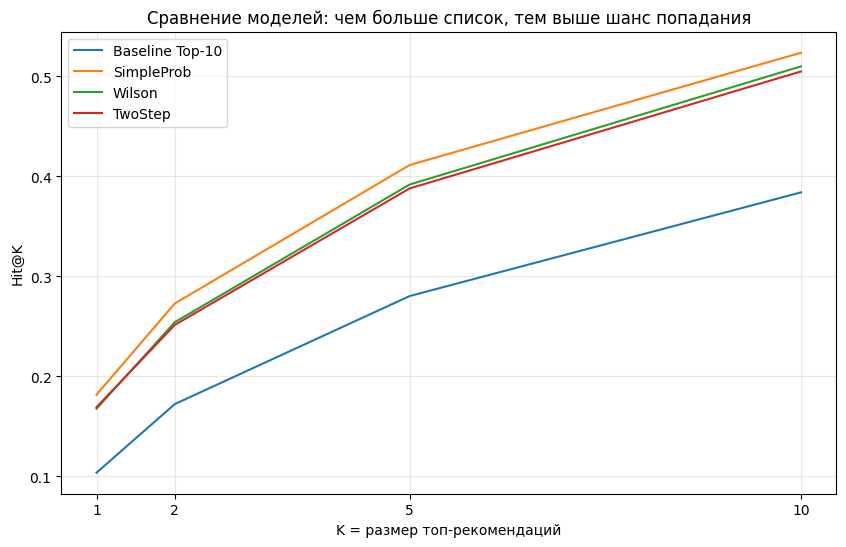


Результаты оценки по разным K:
 K  Baseline Top-10   Simple   Wilson  TwoStep
 1         0.103704 0.181676 0.167641 0.169201
 2         0.172320 0.272904 0.254191 0.251462
 5         0.280312 0.411306 0.391813 0.387914
10         0.384016 0.523587 0.509942 0.504873


In [54]:

k_values = [1, 2, 5, 10]

# Функция для расчёта всех метрик сразу
def get_scores_for_all_k(model, sessions, targets, k_list):
    return [
        eval_model(model, sessions, targets, k)
        for k in k_list
    ]



baseline_rec = [
    simple_prob_model.global_top
    for _ in train_sessions
]

baseline_scores = [
    hit_at_k(baseline_rec, test_targets, k)
    for k in k_values
]


simple_prob_scores = get_scores_for_all_k(
    simple_prob_model,
    train_sessions,
    test_targets,
    k_values
)

wilson_prob_scores = get_scores_for_all_k(
    wilson_prob_model,
    train_sessions,
    test_targets,
    k_values
)

two_step_prob_scores = get_scores_for_all_k(
    two_step_prob_model,
    train_sessions,
    test_targets,
    k_values
)


# График
plt.figure(figsize=(10, 6))

plt.plot(k_values, baseline_scores, label='Baseline Top-10')
plt.plot(k_values, simple_prob_scores, label='SimpleProb')
plt.plot(k_values, wilson_prob_scores, label='Wilson')
plt.plot(k_values, two_step_prob_scores,label='TwoStep')

plt.xlabel('K = размер топ-рекомендаций')
plt.ylabel('Hit@K')
plt.title('Сравнение моделей: чем больше список, тем выше шанс попадания')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()


# Таблица с результатами
data = {
    "K": k_values,
    "Baseline Top-10": baseline_scores,
    "Simple": simple_prob_scores,
    "Wilson": wilson_prob_scores,
    "TwoStep": two_step_prob_scores
}

df_results = pd.DataFrame(data)

print("\nРезультаты оценки по разным K:")
print(df_results.to_string(index=False))

### Итоговый вывод
По результатам оценки видно, что все персонализированные модели заметно лучше базового подхода Baseline Top-10, который рекомендует только самые популярные товары. Например, на Hit@10 baseline показывает 0.3840, а лучшая модель SimpleProbModel — 0.5236. Это значит, что использование графа переходов действительно помогает лучше предсказывать следующий товар пользователя.

Лучший результат показала модель SimpleProbModel. Она использует обычную вероятность перехода между товарами и на всех значениях K показывает наибольший Hit@K:

Hit@1  = 0.1817
Hit@2  = 0.2729
Hit@5  = 0.4113
Hit@10 = 0.5236

Это говорит о том, что последний просмотренный товар является сильным сигналом для рекомендации следующего товара.

Модель WilsonProbModel показала результат немного хуже, чем простая вероятность. На Hit@10 она получила 0.5099 против 0.5236 у SimpleProbModel. Вероятно, в данном датасете сглаживание Уилсона слишком сильно занижает оценки некоторых редких, но полезных переходов. Поэтому для этой задачи обычная вероятность оказалась эффективнее.

Модель TwoStepProbModel, которая учитывает два последних товара, также немного уступила простой модели. На Hit@10 она получила 0.5049. Это может означать, что предпоследний товар добавляет дополнительный шум, а последний товар лучше отражает текущий интерес пользователя.

Также видно, что при увеличении K качество всех моделей растёт. Это ожидаемо: чем больше список рекомендаций, тем выше шанс, что правильный товар попадёт в него.

Итог: лучшей моделью стала SimpleProbModel, так как она показывает максимальное качество на всех отсечках K. Это означает, что для данного датасета наиболее эффективно использовать простую модель на основе вероятностей переходов между соседними товарами с добавлением популярных товаров в качестве fallback-рекомендаций.